In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veri setini okuyoruz
df = pd.read_csv("/content/ecommerce_sales_analytics_5000.csv")

# Veri setinin ilk 5 satırına bakıyoruz
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
# Gelirlerin medyan değeri buluyoruz
medyan_gelir = df['revenue'].median()

# Medyan değerin üstündekilere 1, altındakilere 0 vererek yeni bir hedef sütun yaratıyoruz
df['yuksek_gelir'] = (df['revenue'] > medyan_gelir).astype(int)

# Yeni oluşturduğumuz sütunun dağılımına bakıyoruz
print("Sınıf Dağılımı (0: Düşük Gelir, 1: Yüksek Gelir):")
print(df['yuksek_gelir'].value_counts())

Sınıf Dağılımı (0: Düşük Gelir, 1: Yüksek Gelir):
yuksek_gelir
1    2500
0    2500
Name: count, dtype: int64


In [ ]:
# 1. Özellikleri (X) ve Hedef Değişkeni (y) belirliyoruz
# Tahmin yapmak için sadece sayısal ve anlamlı sütunları seçiyoruz
X = df[['quantity', 'unit_price', 'discount', 'delivery_days']]
y = df['yuksek_gelir']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. k-NN ve SVM için ölçeklendirme (Scaling) yapıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("3. Adım Başarıyla Tamamlandı!")
print(f"Eğitim kümesindeki örnek sayısı: {X_train_scaled.shape[0]}")
print(f"Test kümesindeki örnek sayısı: {X_test_scaled.shape[0]}")

3. Adım Başarıyla Tamamlandı!
Eğitim kümesindeki örnek sayısı: 4000
Test kümesindeki örnek sayısı: 1000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. k-NN modelini tanımlıyoruz (Komşu sayısını k=5 yapıyoruz)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Modeli eğitim verilerimizle eğitiyoruz
knn_model.fit(X_train_scaled, y_train)

# 3. Modelin hiç görmediği test verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Modelin Accuracy skorunu hesaplıyoruz
dogruluk_knn = accuracy_score(y_test, y_pred_knn)

print("4. Adım: k-NN Modeli Başarıyla Eğitildi ve Test Edildi!\n")
print(f"k-NN Modelinin Doğruluk Oranı (Accuracy): %{dogruluk_knn * 100:.2f}")

4. Adım: k-NN Modeli Başarıyla Eğitildi ve Test Edildi!

k-NN Modelinin Doğruluk Oranı (Accuracy): %97.70


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. SVM modelini tanımlıyoruz (Sınıflandırma için SVC kullanıyoruz)
svm_model = SVC(kernel='linear', random_state=42)

# 2. Modeli ölçeklenmiş eğitim verilerimizle eğitiyoruz
svm_model.fit(X_train_scaled, y_train)

# 3. Modelin test verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. SVM modelinin doğruluk (Accuracy) skorunu hesaplıyoruz
dogruluk_svm = accuracy_score(y_test, y_pred_svm)

print("5. Adım: SVM Modeli Başarıyla Eğitildi ve Test Edildi!\n")
print(f"SVM Modelinin Doğruluk Oranı (Accuracy): %{dogruluk_svm * 100:.2f}")

5. Adım: SVM Modeli Başarıyla Eğitildi ve Test Edildi!

SVM Modelinin Doğruluk Oranı (Accuracy): %91.00


/tmp/ipykernel_479/2970046972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=modeller, y=dogruluk_oranlari, palette="Set2")


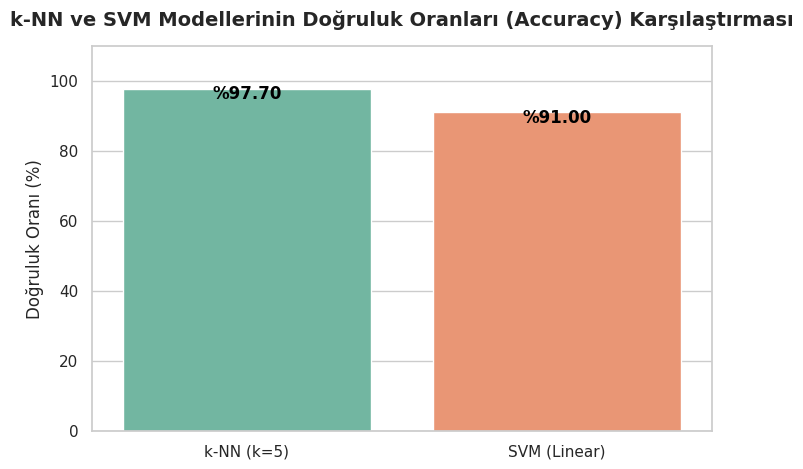

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modellerin doğruluk oranlarını bir sözlükte topluyoruz
modeller = ['k-NN (k=5)', 'SVM (Linear)']
dogruluk_oranlari = [dogruluk_knn * 100, dogruluk_svm * 100]

# 2. Grafik çizimi için arka plan stilini ayarlıyoruz
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Barplot oluşturuyoruz
ax = sns.barplot(x=modeller, y=dogruluk_oranlari, palette="Set2")

# 4. Grafiğin üzerine yüzde değerlerini yazdırıyoruz
for p in ax.patches:
    ax.annotate(f"%{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='black')

# 5. Grafik başlıkları ve sınırları
plt.title("k-NN ve SVM Modellerinin Doğruluk Oranları (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Doğruluk Oranı (%)", fontsize=12)
plt.ylim(0, 110)

# Grafiği ekranda gösteriyoruz
plt.show()